In [7]:
import pandas as pd
df = pd.read_excel(r'C:\Users\SERVER\Downloads\customer_reviews_dataset.xlsx')
x = df[['age', 'income']]
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = scaler.fit_transform(x)

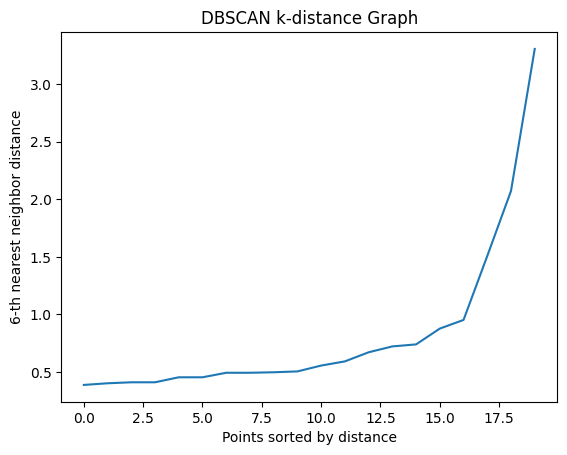

In [32]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt

k = 6  # usually = min_samples
neighbors = NearestNeighbors(n_neighbors=k)
neighbors_fit = neighbors.fit(X)
distances, indices = neighbors_fit.kneighbors(X)

# Take the k-th nearest distance for each point
k_distances = np.sort(distances[:, k-1])

plt.plot(k_distances)
plt.xlabel('Points sorted by distance')
plt.ylabel(f'{k}-th nearest neighbor distance')
plt.title('DBSCAN k-distance Graph')
plt.show()

In [45]:
from sklearn.cluster import DBSCAN
db = DBSCAN(eps=0.6, min_samples=3)
labels = db.fit_predict(X)

In [46]:
import pandas as pd
pd.Series(labels).value_counts()

 0    17
-1     3
Name: count, dtype: int64

C:\Users\SERVER\AppData\Local\Temp\ipykernel_10828\368136698.py:4: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(x.iloc[:, 0], x.iloc[:, 1], c=colors, cmap='viridis', s=50)


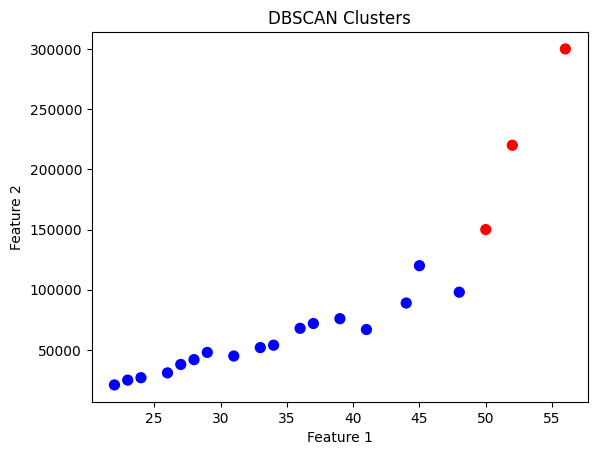

In [47]:
%matplotlib inline
import matplotlib.pyplot as plt
colors = np.array(['red' if label==-1 else 'blue' for label in labels])
plt.scatter(x.iloc[:, 0], x.iloc[:, 1], c=colors, cmap='viridis', s=50)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('DBSCAN Clusters')
plt.show()

In [17]:
pd.Series(labels).value_counts()
x['clusters'] = labels

In [18]:
x

,age,income,clusters
0,23,25000,0
1,45,120000,0
2,34,54000,0
3,29,48000,0
4,52,220000,-1
5,41,67000,0
6,37,72000,0
7,26,31000,0
8,48,98000,0
9,31,45000,0


In [48]:
from sklearn.metrics import silhouette_score
score = silhouette_score(X, labels)
print(score)

0.5975024533222825


In [50]:
x['cluster_binary'] = x['clusters'].apply(lambda x: 0 if x==0 else 1)
from sklearn.model_selection import train_test_split

X = x.drop('clusters', axis=1)  
y = x['clusters']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [51]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [52]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

model = LogisticRegression()
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 1.0


In [53]:
X_train_scaled

array([[ 1.15710833,  0.19038861, -0.48038446],
       [ 0.47859455, -0.2256147 , -0.48038446],
       [ 1.93255266,  2.90111987,  2.081666  ],
       [-0.68457195, -0.48058447, -0.48038446],
       [ 1.35096942,  0.88820062,  2.081666  ],
       [-0.78150249, -0.56110124, -0.48038446],
       [-1.36308573, -0.84290994, -0.48038446],
       [-0.19991924, -0.4000677 , -0.48038446],
       [-0.49071086, -0.52084286, -0.48038446],
       [-1.16922465, -0.76239317, -0.48038446],
       [ 1.5448305 ,  1.82756294,  2.081666  ],
       [-0.29684978, -0.42690662, -0.48038446],
       [-0.97536357, -0.70871532, -0.48038446],
       [-0.87843303, -0.61477909, -0.48038446],
       [ 0.28473346, -0.10483954, -0.48038446],
       [ 0.09087238, -0.15851739, -0.48038446]])